In [11]:
from google.colab import drive
# Load the data set and unzip it.
drive.mount('/content/drive')
import zipfile
zip_path = '/content/drive/MyDrive/Snake_FeaturedDataset.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Dataset extracted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully!


In [13]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
import pandas as pd
import os
import time
import warnings
warnings.filterwarnings('ignore')

In [14]:
# 1. DATA LOADING

# Load preprocessed features
features_path = "/content"
X = np.load(os.path.join(features_path, "selected_features.npy"))
y = np.load(os.path.join(features_path, "labels.npy"))

print(f"• Features shape: {X.shape}")
print(f"• Labels shape: {y.shape}")
print(f"• Classes: {np.unique(y)}")
print(f"• Class distribution: {np.bincount(y.astype(int))}")

• Features shape: (33117, 500)
• Labels shape: (33117,)
• Classes: [0. 1.]
• Class distribution: [16557 16560]


In [15]:
# 2. MULTIPLE PRE-PROCESSING VARIETIES

preprocessing_results = {}

# Method 1: Standard Scaler (Best for MLP)
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)
preprocessing_results['StandardScaler'] = X_standard
print("    StandardScaler applied")

# Method 2: MinMax Scaler
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)
preprocessing_results['MinMaxScaler'] = X_minmax
print("    MinMaxScaler applied")

# Method 3: Robust Scaler (Handles outliers)
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)
preprocessing_results['RobustScaler'] = X_robust
print("    RobustScaler applied")

print(" 3 Pre-processing methods applied successfully")

    StandardScaler applied
    MinMaxScaler applied
    RobustScaler applied
 3 Pre-processing methods applied successfully


In [16]:
# 3. MLP ARCHITECTURE VARIANTS (DIFFERENT HYPERPARAMETERS)


def create_mlp_small(input_dim, activation='relu'):
    """Small MLP: 2 hidden layers - efficient"""
    print(f"   Creating Small MLP with {input_dim} input features")
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    return model

def create_mlp_medium(input_dim, activation='relu'):
    """Medium MLP: 3 hidden layers - balanced"""
    print(f"   Creating Medium MLP with {input_dim} input features")
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation=activation),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    return model

def create_mlp_large(input_dim, activation='relu'):
    """Large MLP: 4 hidden layers - complex"""
    print(f"   Creating Large MLP with {input_dim} input features")
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(512, activation=activation),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation=activation),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    return model

# MLP configurations with different hyperparameters
mlp_configurations = {
    'MLP_Small': {'func': create_mlp_small, 'activation': 'relu', 'learning_rate': 0.001},
    'MLP_Medium': {'func': create_mlp_medium, 'activation': 'relu', 'learning_rate': 0.001},
    'MLP_Large': {'func': create_mlp_large, 'activation': 'relu', 'learning_rate': 0.0005},
}

print(" 3 MLP architecture variants defined:")
for config_name, params in mlp_configurations.items():
    print(f"   • {config_name}: {params['activation']} activation, lr={params['learning_rate']}")


 3 MLP architecture variants defined:
   • MLP_Small: relu activation, lr=0.001
   • MLP_Medium: relu activation, lr=0.001
   • MLP_Large: relu activation, lr=0.0005


In [17]:
# 4. COMPREHENSIVE EVALUATION FUNCTION

def evaluate_mlp_model(config_name, mlp_params, preprocessing_name, X_processed, y_data):
    """Evaluate MLP with specific configuration and pre-processing"""
    print(f"\n EVALUATING: {config_name} with {preprocessing_name}")
    print(f"   Input shape: {X_processed.shape}")

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_processed, y_data, test_size=0.2, random_state=42, stratify=y_data
    )

    print(f"   Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

    # Convert to categorical
    y_train_cat = to_categorical(y_train, 2)
    y_val_cat = to_categorical(y_val, 2)

    # Compute class weights
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print(f"   Class weights: {class_weight_dict}")

    # Create model
    print(f"   Building model architecture...")
    model = mlp_params['func'](X_train.shape[1], mlp_params['activation'])

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=mlp_params['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"   Model compiled with {model.count_params():,} parameters")

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            patience=5,
            factor=0.5,
            min_lr=1e-7,
            verbose=0
        )
    ]

    # Train model
    print(f"   Starting training...")
    start_time = time.time()
    history = model.fit(
        X_train, y_train_cat,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val_cat),
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    training_time = time.time() - start_time

    print(f"   Training completed in {training_time:.2f} seconds")
    print(f"   Final epoch: {len(history.history['val_loss'])}")

    # Predictions
    print(f"   Making predictions...")
    y_pred_proba = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_val_cat, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    auc_score = roc_auc_score(y_true, y_pred_proba[:, 1])

    print(f"    RESULTS - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc_score:.4f}")

    # Count layers
    dense_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dense)]
    hidden_layers = len(dense_layers) - 1

    return {
        'config_name': config_name,
        'preprocessing': preprocessing_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_score,
        'training_time': training_time,
        'final_epoch': len(history.history['val_loss']),
        'parameters': model.count_params(),
        'hidden_layers': hidden_layers,
        'activation': mlp_params['activation'],
        'learning_rate': mlp_params['learning_rate'],
        'model_object': model,
        'history': history,
        'X_val': X_val,
        'y_val': y_val_cat,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }


In [18]:
# 5. COMPREHENSIVE MODEL EVALUATION

all_results = []

# Evaluate all combinations of configurations and pre-processing
total_combinations = len(mlp_configurations) * len(preprocessing_results)
current_combination = 0

for config_name, mlp_params in mlp_configurations.items():
    for preproc_name, X_processed in preprocessing_results.items():
        current_combination += 1
        print(f"\n COMBINATION {current_combination}/{total_combinations}")

        result = evaluate_mlp_model(
            config_name, mlp_params, preproc_name, X_processed, y
        )
        all_results.append(result)

        # Clear memory
        tf.keras.backend.clear_session()
        print(f" Combination {current_combination} completed")

print(f"\n COMPLETED ALL {total_combinations} MLP EVALUATIONS!")


 COMBINATION 1/9

 EVALUATING: MLP_Small with StandardScaler
   Input shape: (33117, 500)
   Training samples: 26493, Validation samples: 6624
   Class weights: {0: np.float64(1.0001132502831258), 1: np.float64(0.9998867753623188)}
   Building model architecture...
   Creating Small MLP with 500 input features
   Model compiled with 72,514 parameters
   Starting training...
Epoch 1/50
828/828 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6223 - loss: 0.6945 - val_accuracy: 0.7014 - val_loss: 0.5659 - learning_rate: 0.0010
Epoch 2/50
828/828 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7008 - loss: 0.5602 - val_accuracy: 0.7163 - val_loss: 0.5406 - learning_rate: 0.0010
Epoch 3/50
828/828 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7253 - loss: 0.5268 - val_accuracy: 0.7274 - val_loss: 0.5301 - learning_rate: 0.0010
Epoch 4/50
828/828 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7436 - loss: 0.5031 - val_accuracy: 0.7274 - val_loss: 0.5261 - learning_rate: 0.0010
Epoch 5/50
828

In [19]:
# 6. COMPREHENSIVE RESULTS ANALYSIS

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

# Display comprehensive results
print("\n" + "="*100)
print(" MLP - COMPREHENSIVE PERFORMANCE COMPARISON (ARCHITECTURES + PRE-PROCESSING)")
print("="*100)

# Sort by F1-score
results_sorted = results_df.sort_values('f1', ascending=False)

print("\n TOP 10 PERFORMING CONFIGURATIONS:")
top_10_display = results_sorted[['config_name', 'preprocessing', 'f1', 'accuracy', 'auc_roc', 'training_time', 'hidden_layers']].round(4).head(10)
print(top_10_display.to_string(index=False))

# Best overall model
best_overall = results_sorted.iloc[0]
print(f"\n BEST OVERALL CONFIGURATION:")
print(f"   • Architecture: {best_overall['config_name']}")
print(f"   • Pre-processing: {best_overall['preprocessing']}")
print(f"   • F1-Score: {best_overall['f1']:.4f}")
print(f"   • Accuracy: {best_overall['accuracy']:.4f}")
print(f"   • AUC-ROC: {best_overall['auc_roc']:.4f}")
print(f"   • Training Time: {best_overall['training_time']:.2f}s")
print(f"   • Hidden Layers: {best_overall['hidden_layers']}")
print(f"   • Parameters: {best_overall['parameters']:,}")

# Analysis by architecture
print(f"\n ARCHITECTURE IMPACT ANALYSIS:")
arch_analysis = results_df.groupby('config_name').agg({
    'f1': ['mean', 'max', 'min'],
    'accuracy': 'mean',
    'training_time': 'mean',
    'parameters': 'mean'
}).round(4)
print(arch_analysis)

# Analysis by pre-processing
print(f"\n PRE-PROCESSING IMPACT ANALYSIS:")
preproc_analysis = results_df.groupby('preprocessing').agg({
    'f1': ['mean', 'max', 'min'],
    'accuracy': 'mean',
    'training_time': 'mean'
}).round(4)
print(preproc_analysis)

# Analysis by activation function
print(f"\n ACTIVATION FUNCTION IMPACT:")
activation_analysis = results_df.groupby('activation').agg({
    'f1': ['mean', 'max'],
    'accuracy': 'mean',
    'training_time': 'mean'
}).round(4)
print(activation_analysis)


 MLP - COMPREHENSIVE PERFORMANCE COMPARISON (ARCHITECTURES + PRE-PROCESSING)

 TOP 10 PERFORMING CONFIGURATIONS:
config_name  preprocessing     f1  accuracy  auc_roc  training_time  hidden_layers
  MLP_Large StandardScaler 0.7783    0.7790   0.8645       296.9492              4
 MLP_Medium StandardScaler 0.7679    0.7681   0.8561       138.4233              3
  MLP_Small StandardScaler 0.7601    0.7603   0.8483        74.1935              2
  MLP_Large   MinMaxScaler 0.7583    0.7597   0.8440       362.1475              4
  MLP_Large   RobustScaler 0.7549    0.7550   0.8363       239.6278              4
 MLP_Medium   MinMaxScaler 0.7518    0.7524   0.8399       219.0054              3
 MLP_Medium   RobustScaler 0.7482    0.7482   0.8362       119.9996              3
  MLP_Small   MinMaxScaler 0.7384    0.7396   0.8275       100.8674              2
  MLP_Small   RobustScaler 0.7242    0.7243   0.8055        56.3712              2

 BEST OVERALL CONFIGURATION:
   • Architecture: MLP_Lar

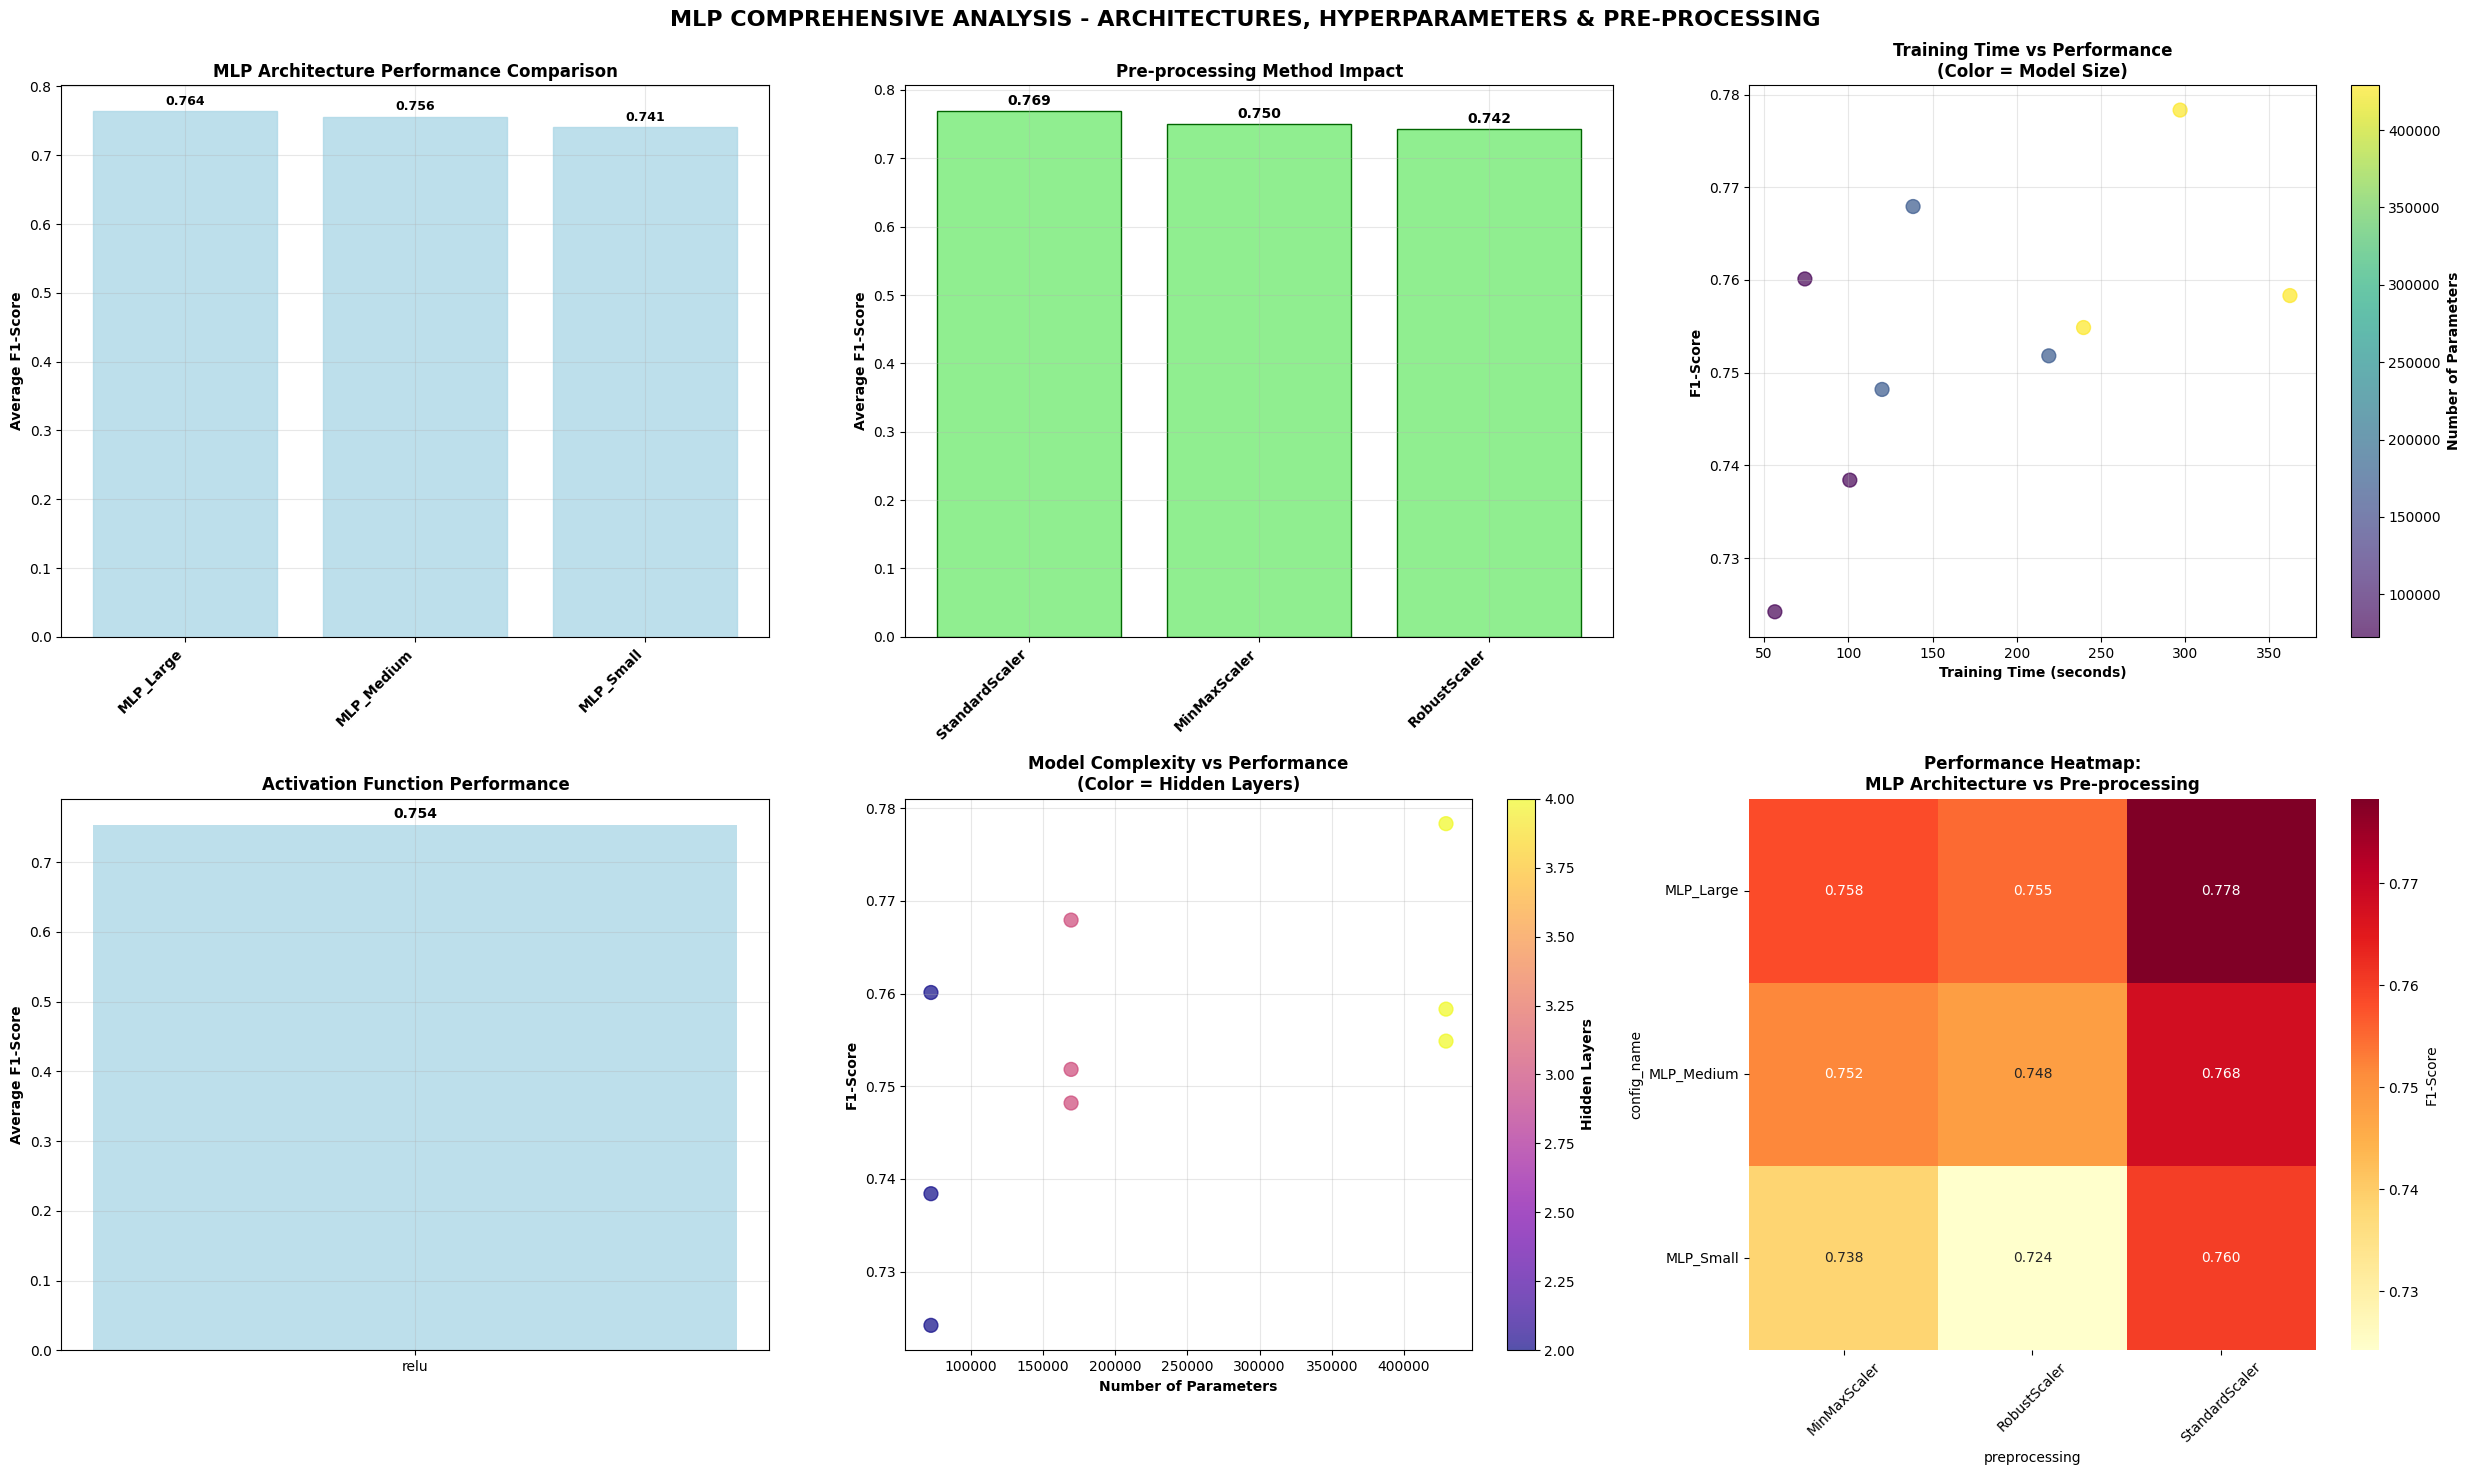

In [20]:
# 7. ADVANCED VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(25, 15))
fig.suptitle('MLP COMPREHENSIVE ANALYSIS - ARCHITECTURES, HYPERPARAMETERS & PRE-PROCESSING',
             fontsize=16, fontweight='bold')

# 1. Performance Comparison (F1-Score) by Architecture
arch_f1 = results_df.groupby('config_name')['f1'].mean().sort_values(ascending=False)
bars = axes[0,0].bar(range(len(arch_f1)), arch_f1.values, color='lightblue', edgecolor='navy', alpha=0.8)
axes[0,0].set_xticks(range(len(arch_f1)))
axes[0,0].set_xticklabels(arch_f1.index, rotation=45, ha='right', fontweight='bold')
axes[0,0].set_ylabel('Average F1-Score', fontweight='bold')
axes[0,0].set_title('MLP Architecture Performance Comparison', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Color bars by activation function
for i, (config_name, value) in enumerate(arch_f1.items()):
    color = 'lightcoral' if 'Tanh' in config_name else 'lightblue'
    bars[i].set_color(color)
    axes[0,0].text(i, value + 0.005, f'{value:.3f}', ha='center', va='bottom',
                   fontweight='bold', fontsize=9)

# 2. Pre-processing Impact on F1-Score
preproc_f1 = results_df.groupby('preprocessing')['f1'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(preproc_f1)), preproc_f1.values, color='lightgreen', edgecolor='darkgreen')
axes[0,1].set_xticks(range(len(preproc_f1)))
axes[0,1].set_xticklabels(preproc_f1.index, rotation=45, ha='right', fontweight='bold')
axes[0,1].set_ylabel('Average F1-Score', fontweight='bold')
axes[0,1].set_title('Pre-processing Method Impact', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

for i, v in enumerate(preproc_f1.values):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. Training Time vs Performance
axes[0,2].scatter(results_df['training_time'], results_df['f1'],
                  c=results_df['parameters'], cmap='viridis', s=100, alpha=0.7)
axes[0,2].set_xlabel('Training Time (seconds)', fontweight='bold')
axes[0,2].set_ylabel('F1-Score', fontweight='bold')
axes[0,2].set_title('Training Time vs Performance\n(Color = Model Size)', fontweight='bold')
axes[0,2].grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(axes[0,2].collections[0], ax=axes[0,2])
cbar.set_label('Number of Parameters', fontweight='bold')

# 4. Activation Function Comparison
activation_f1 = results_df.groupby('activation')['f1'].mean()
axes[1,0].bar(activation_f1.index, activation_f1.values, color=['lightblue', 'lightcoral'], alpha=0.8)
axes[1,0].set_ylabel('Average F1-Score', fontweight='bold')
axes[1,0].set_title('Activation Function Performance', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

for i, v in enumerate(activation_f1.values):
    axes[1,0].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 5. Model Complexity vs Performance
axes[1,1].scatter(results_df['parameters'], results_df['f1'],
                  c=results_df['hidden_layers'], cmap='plasma', s=100, alpha=0.7)
axes[1,1].set_xlabel('Number of Parameters', fontweight='bold')
axes[1,1].set_ylabel('F1-Score', fontweight='bold')
axes[1,1].set_title('Model Complexity vs Performance\n(Color = Hidden Layers)', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

cbar2 = plt.colorbar(axes[1,1].collections[0], ax=axes[1,1])
cbar2.set_label('Hidden Layers', fontweight='bold')

# 6. Performance Heatmap (Architecture vs Pre-processing)
pivot_data = results_df.pivot(index='config_name', columns='preprocessing', values='f1')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1,2],
            cbar_kws={'label': 'F1-Score'})
axes[1,2].set_title('Performance Heatmap:\nMLP Architecture vs Pre-processing', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

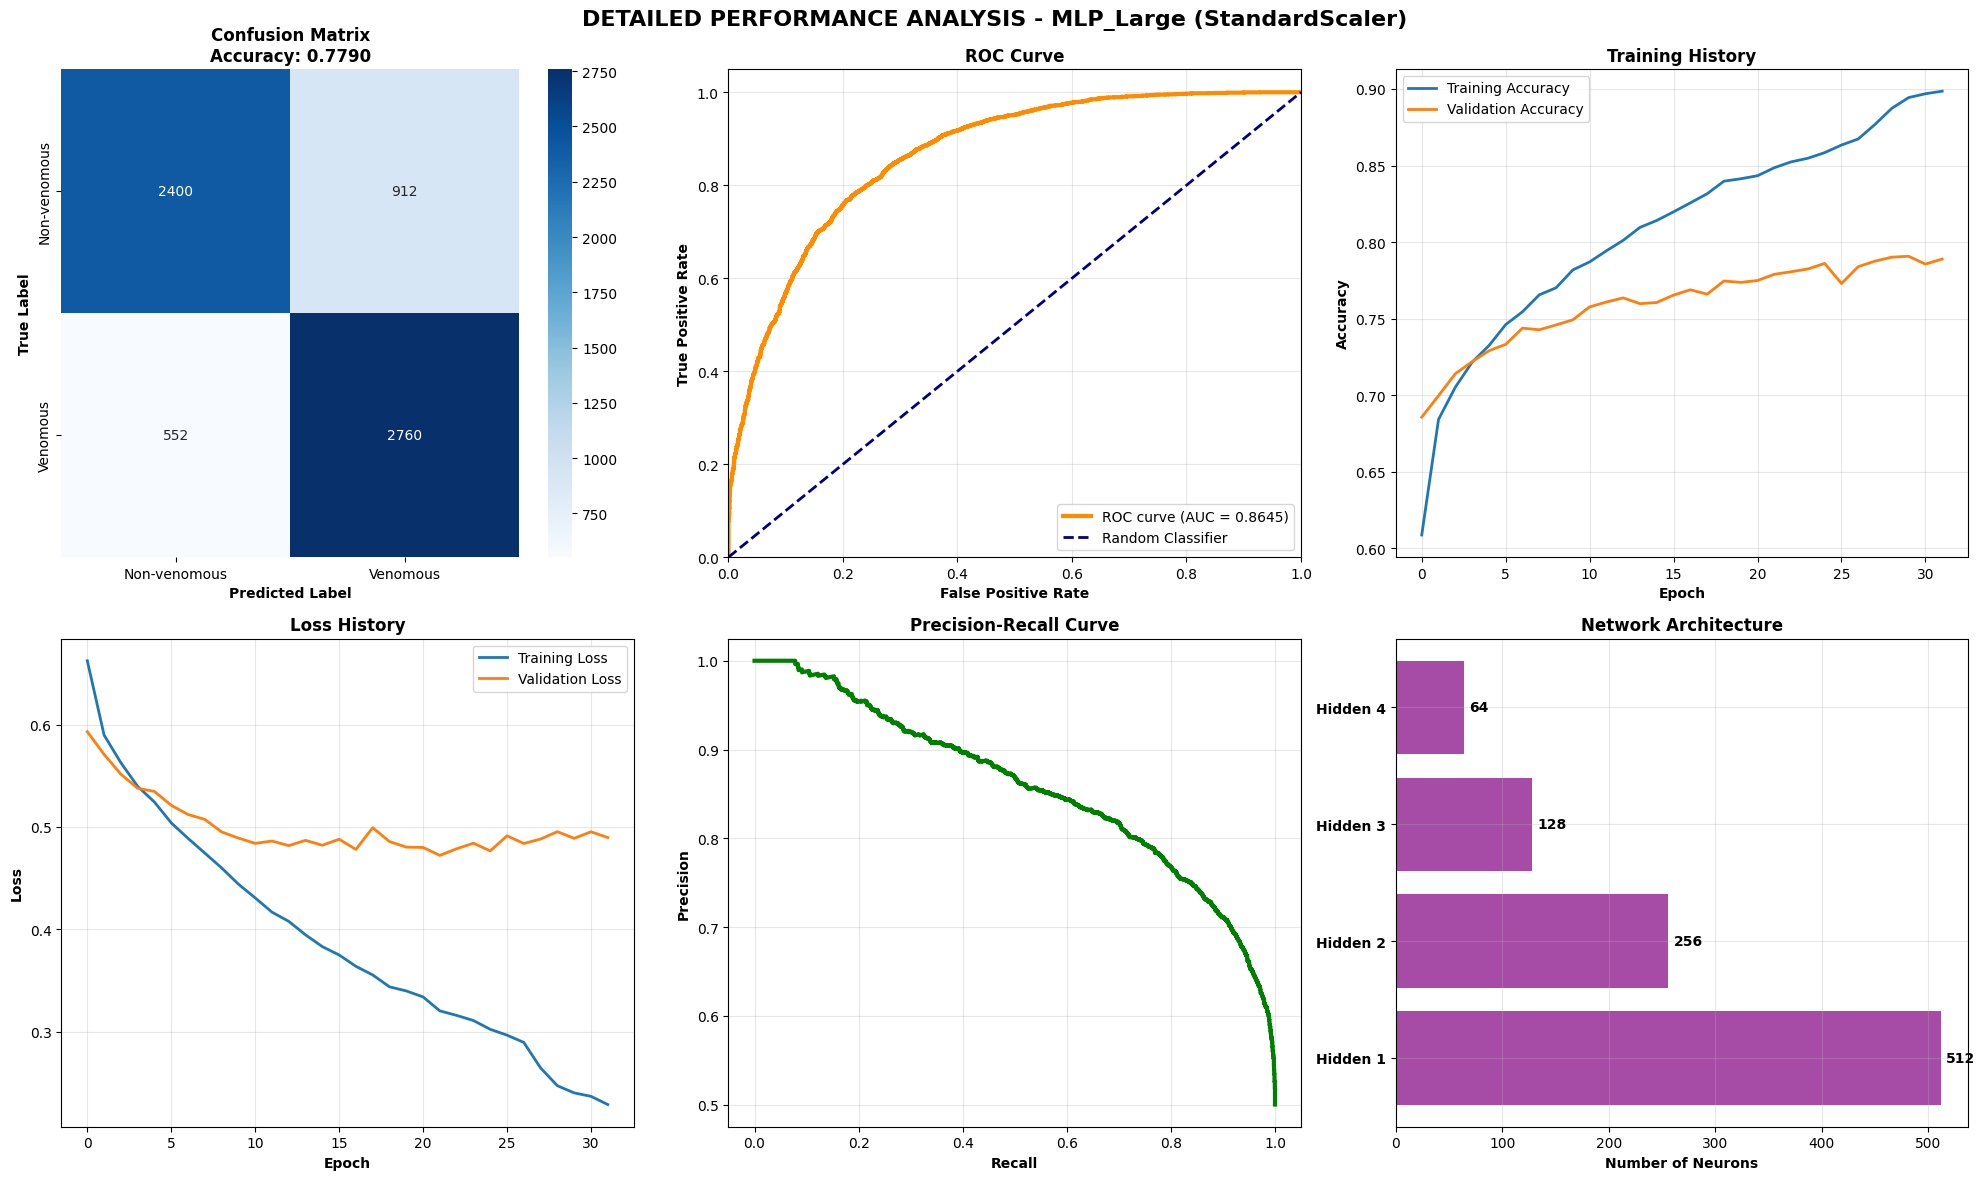

In [21]:
# 8. DETAILED BEST MODEL ANALYSIS

best_model = best_overall['model_object']
X_val_best = best_overall['X_val']
y_val_best = best_overall['y_val']
y_pred_best = best_overall['y_pred']
y_pred_proba_best = best_overall['y_pred_proba']
y_true_best = np.argmax(y_val_best, axis=1)

# Create detailed evaluation figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'DETAILED PERFORMANCE ANALYSIS - {best_overall["config_name"]} ({best_overall["preprocessing"]})',
             fontsize=16, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_true_best, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Non-venomous', 'Venomous'],
            yticklabels=['Non-venomous', 'Venomous'])
axes[0,0].set_title(f'Confusion Matrix\nAccuracy: {best_overall["accuracy"]:.4f}', fontweight='bold')
axes[0,0].set_xlabel('Predicted Label', fontweight='bold')
axes[0,0].set_ylabel('True Label', fontweight='bold')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_true_best, y_pred_proba_best[:, 1])
roc_auc = auc(fpr, tpr)

axes[0,1].plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate', fontweight='bold')
axes[0,1].set_ylabel('True Positive Rate', fontweight='bold')
axes[0,1].set_title('ROC Curve', fontweight='bold')
axes[0,1].legend(loc="lower right")
axes[0,1].grid(True, alpha=0.3)

# 3. Training History
history = best_overall['history']
axes[0,2].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0,2].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0,2].set_xlabel('Epoch', fontweight='bold')
axes[0,2].set_ylabel('Accuracy', fontweight='bold')
axes[0,2].set_title('Training History', fontweight='bold')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Loss History
axes[1,0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1,0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1,0].set_xlabel('Epoch', fontweight='bold')
axes[1,0].set_ylabel('Loss', fontweight='bold')
axes[1,0].set_title('Loss History', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true_best, y_pred_proba_best[:, 1])
axes[1,1].plot(recall_vals, precision_vals, color='green', lw=3)
axes[1,1].set_xlabel('Recall', fontweight='bold')
axes[1,1].set_ylabel('Precision', fontweight='bold')
axes[1,1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

# 6. Architecture Diagram (Simplified)
layers = [layer for layer in best_model.layers if isinstance(layer, tf.keras.layers.Dense)]
layer_sizes = [layer.units for layer in layers[:-1]]  # Exclude output layer

axes[1,2].barh(range(len(layer_sizes)), layer_sizes, color='purple', alpha=0.7)
axes[1,2].set_yticks(range(len(layer_sizes)))
axes[1,2].set_yticklabels([f'Hidden {i+1}' for i in range(len(layer_sizes))], fontweight='bold')
axes[1,2].set_xlabel('Number of Neurons', fontweight='bold')
axes[1,2].set_title('Network Architecture', fontweight='bold')
axes[1,2].grid(True, alpha=0.3)

for i, v in enumerate(layer_sizes):
    axes[1,2].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


In [25]:
# 9. DETAILED CLASSIFICATION REPORT

print(f"\n DETAILED CLASSIFICATION REPORT:")
print(f"Best Architecture: {best_overall['config_name']}")
print(f"Best Pre-processing: {best_overall['preprocessing']}")
print(f"Activation: {best_overall['activation']}")
print(f"Learning Rate: {best_overall['learning_rate']}")
print("="*70)
print(classification_report(y_true_best, y_pred_best,
                          target_names=['Non-venomous', 'Venomous']))


 DETAILED CLASSIFICATION REPORT:
Best Architecture: MLP_Large
Best Pre-processing: StandardScaler
Activation: relu
Learning Rate: 0.0005
              precision    recall  f1-score   support

Non-venomous       0.81      0.72      0.77      3312
    Venomous       0.75      0.83      0.79      3312

    accuracy                           0.78      6624
   macro avg       0.78      0.78      0.78      6624
weighted avg       0.78      0.78      0.78      6624



In [27]:
# 10. SUMMARY AND CONCLUSIONS

print(f" CONFIGURATIONS TESTED: {len(results_df)} (3 architectures × 3 pre-processing)")
print(f" PERFORMANCE RANGE: F1-Score {results_df['f1'].min():.3f} - {results_df['f1'].max():.3f}")

print(f"\n BEST COMBINATION:")
print(f"   • {best_overall['config_name']} + {best_overall['preprocessing']}")
print(f"   • F1-Score: {best_overall['f1']:.3f}, Accuracy: {best_overall['accuracy']:.3f}")

# Save best model

best_model.save('best_mlp_snake_classifier.h5')
print(" Best model saved as 'best_mlp_snake_classifier.h5'")


 CONFIGURATIONS TESTED: 9 (3 architectures × 3 pre-processing)
 PERFORMANCE RANGE: F1-Score 0.724 - 0.778

 BEST COMBINATION:
   • MLP_Large + StandardScaler
   • F1-Score: 0.778, Accuracy: 0.779
 Best model saved as 'best_mlp_snake_classifier.h5'
